In [17]:
!pip install tensorflow==2.18.0 --upgrade --quiet
!pip install antspyx --quiet
!pip install antspynet --quiet

^C
ERROR: Operation cancelled by user
^C
ERROR: Operation cancelled by user
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.11.0 requires tensorflow==2.18.0, but you have tensorflow 2.17.0 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
tf-keras 2.18.0 requires tensorflow<2.19,>=2.18, but you have tensorflow 2.17.0 which is incompatible.
tensorflow-text 2.18.1 requires tensorflow<2.19,>=2.18.0, but you have tensorflow 2.17.0 which is incompatible.


In [18]:
import numpy as np
import zipfile
import os
import matplotlib.pyplot as plt
import ants
import antspynet

In [19]:
# Replace with your root dataset directory
root_dir = "/kaggle/input/week4-dataset/ADNI"

# Collect all NIfTI files
nii_files = []

for root, dirs, files in os.walk(root_dir):
    for file in files:
        if file.endswith(".nii") or file.endswith(".nii.gz"):
            nii_files.append(os.path.join(root, file))

print(f"Found {len(nii_files)} NIfTI files")
# print(nii_files[:3])  # Show first 3

Found 459 NIfTI files


(256, 256, 166)


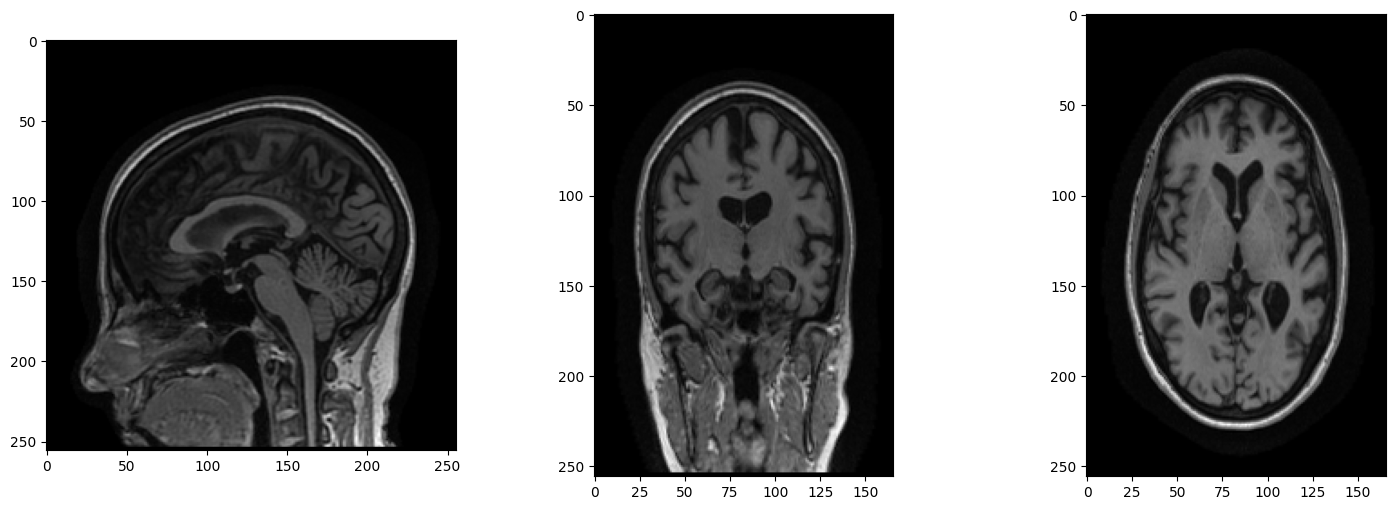

In [20]:
import nibabel as nib

first_nii = nii_files[0]
img = nib.load(first_nii)
data = img.get_fdata()

# Visualize central axial slice (XY plane)
print(data.shape)
plt.figure(figsize=(18, 6))
plt.subplot(1,3,1)
plt.imshow(data[:, :, data.shape[2] // 2], cmap="gray") #subplot 1
plt.subplot(1,3,2)
plt.imshow(data[:, data.shape[1] // 2, :], cmap="gray") #subplot 2
plt.subplot(1,3,3)
plt.imshow(data[data.shape[0] // 2, :, :], cmap="gray") #subplot 3
plt.show()

5683832/5683832 ━━━━━━━━━━━━━━━━━━━━ 10s 2us/step
14969865/14969865 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
(256, 256, 166)


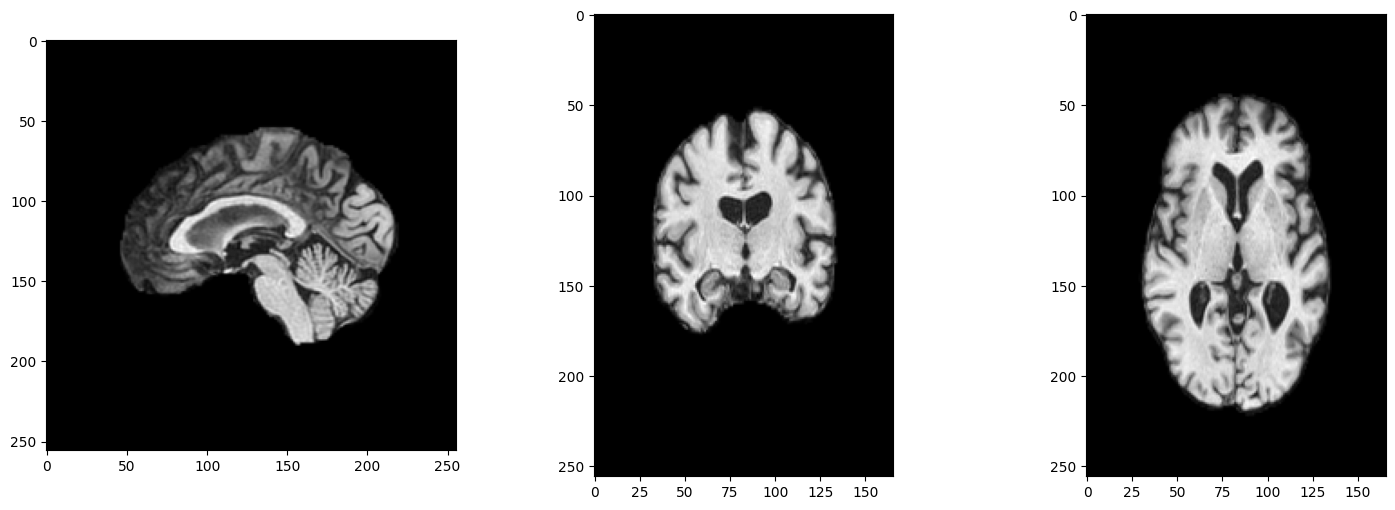

In [25]:
ants_img = ants.image_read(nii_files[0])  

# Step 2: Run brain extraction to get binary mask
mask = antspynet.brain_extraction(ants_img, modality="t1")

# Step 3: Apply mask to image
masked = ants_img * mask  # this keeps intensity only where mask == 1

# Step 4: Visualize central slices
data = masked.numpy()  # get raw array from ANTsImage

print(data.shape)
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(data[:, :, data.shape[2] // 2], cmap="gray")
plt.subplot(1, 3, 2)
plt.imshow(data[:, data.shape[1] // 2, :], cmap="gray")
plt.subplot(1, 3, 3)
plt.imshow(data[data.shape[0] // 2, :, :], cmap="gray")
plt.show()